<a href="https://colab.research.google.com/github/emaudealtema/Computer_vision_repo/blob/main/Uqar_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from fastai.callback.all import *
from fastai.vision.all import *
from fastai.callback.all import CSVLogger, SaveModelCallback
from torchvision.models import efficientnet_b0

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [5]:
%matplotlib inline

In [6]:
!wget https://www.dropbox.com/s/u83ae1efaah2w9o/UCMercedLanduse.zip
!unzip UCMercedLanduse.zip


--2026-04-04 22:02:57--  https://www.dropbox.com/s/u83ae1efaah2w9o/UCMercedLanduse.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/dlrn78p72m1wxdyc1y2l9/UCMercedLanduse.zip?rlkey=hsu2tnwvszcb2i7ewoyuvt34p [following]
--2026-04-04 22:02:58--  https://www.dropbox.com/scl/fi/dlrn78p72m1wxdyc1y2l9/UCMercedLanduse.zip?rlkey=hsu2tnwvszcb2i7ewoyuvt34p
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc6a4c7536f27e7036ee20308b87.dl.dropboxusercontent.com/cd/0/inline/C99BI8NpWUWJNZvaRbNBYNvlMBOFtfLAMAhdpZKlyYFWGlPDEpiKmuChZnd-qFO0ixXA5dkxKBi7__P4HcprZncInvKSKksddyEwrpio4h60zVKkto-r5coqomF32matocQm9ZzNG_YcTWkyOMFfK-Zg/file# [following]
--2026-04-04 22:02:58--  https://uc6a4c7536f27e7036ee20308b87.dl.dropboxuserc

In [7]:
df = pd.read_csv("UCMerced/multilabels.txt", sep="\t")
df.head(10)

,IMAGE\LABEL,airplane,bare-soil,buildings,cars,chaparral,court,dock,field,grass,mobile-home,pavement,sand,sea,ship,tanks,trees,water
0,agricultural00,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1,agricultural01,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,agricultural02,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,agricultural03,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,agricultural04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
5,agricultural05,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
6,agricultural06,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
7,agricultural07,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
8,agricultural08,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
9,agricultural09,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(2100, 18)

In [9]:
class_count = pd.DataFrame(df.sum(axis=0)).reset_index()
class_count.columns = ["class", "Count"]
class_count.drop(class_count.index[0], inplace=True)
class_count

,class,Count
1,airplane,100
2,bare-soil,718
3,buildings,691
4,cars,886
5,chaparral,115
6,court,105
7,dock,100
8,field,103
9,grass,975
10,mobile-home,102


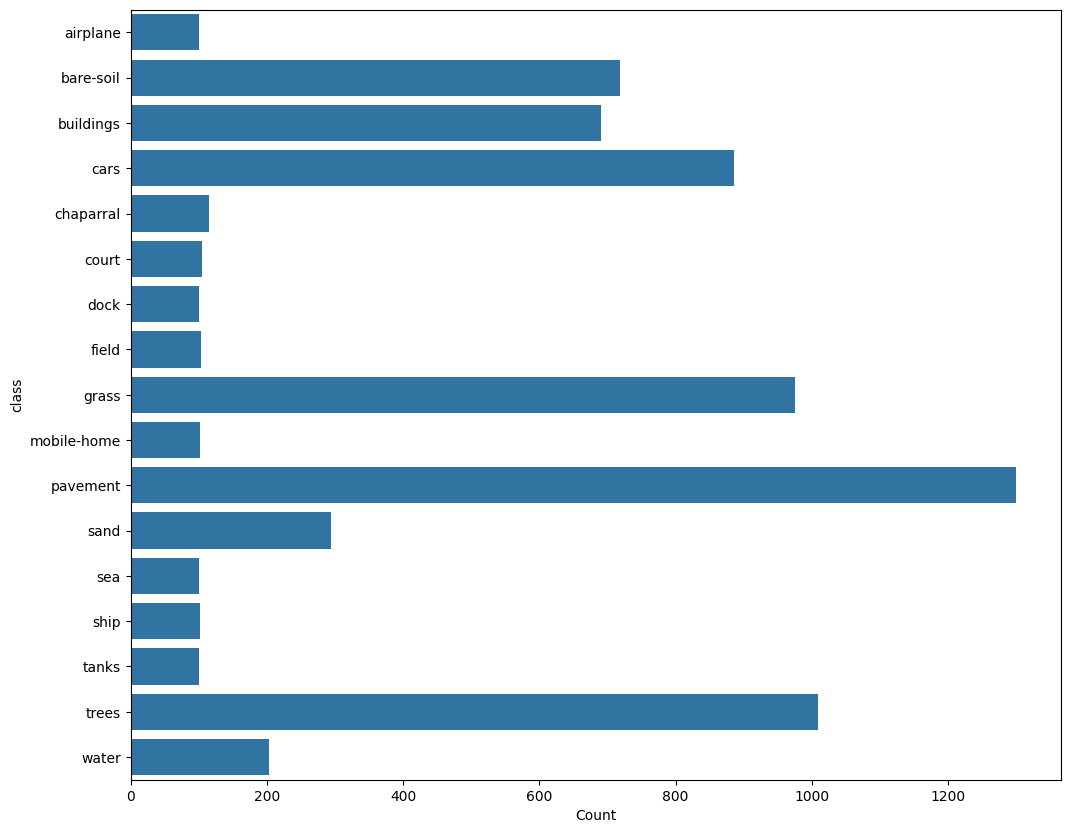

In [10]:
fig, ax= plt.subplots(figsize=(12,10))
sns.barplot(y="class", x="Count",  data=class_count, ax=ax);

In [11]:
list(class_count['class'])

['airplane',
 'bare-soil',
 'buildings',
 'cars',
 'chaparral',
 'court',
 'dock',
 'field',
 'grass',
 'mobile-home',
 'pavement',
 'sand',
 'sea',
 'ship',
 'tanks',
 'trees',
 'water']

In [12]:
from pathlib import Path

path = Path("UCMerced")

print("Niveau 1 :", path.ls())

for p in path.ls():
    if p.is_dir():
        print(f"\nContenu de {p} :", p.ls()[:5])

Niveau 1 : [Path('UCMerced/images'), Path('UCMerced/multilabels.txt')]

Contenu de UCMerced/images : [Path('UCMerced/images/denseresidential84.tif'), Path('UCMerced/images/harbor64.tif'), Path('UCMerced/images/baseballdiamond45.tif'), Path('UCMerced/images/buildings63.tif'), Path('UCMerced/images/parkinglot42.tif')]


In [13]:
from fastai.vision.all import *
import re

path = Path("UCMerced/images")  # 🔥 on pointe directement vers images

# Fonction pour extraire le label
def get_label(x):
    return re.match(r"[a-zA-Z]+", x.stem).group()

# DataBlock corrigé
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_label,   # 🔥 ici la correction clé
    item_tfms=Resize(256),
    batch_tfms=aug_transforms(
        flip_vert=True,
        max_lighting=0.1,
        max_zoom=1.05,
        max_warp=0.)
)



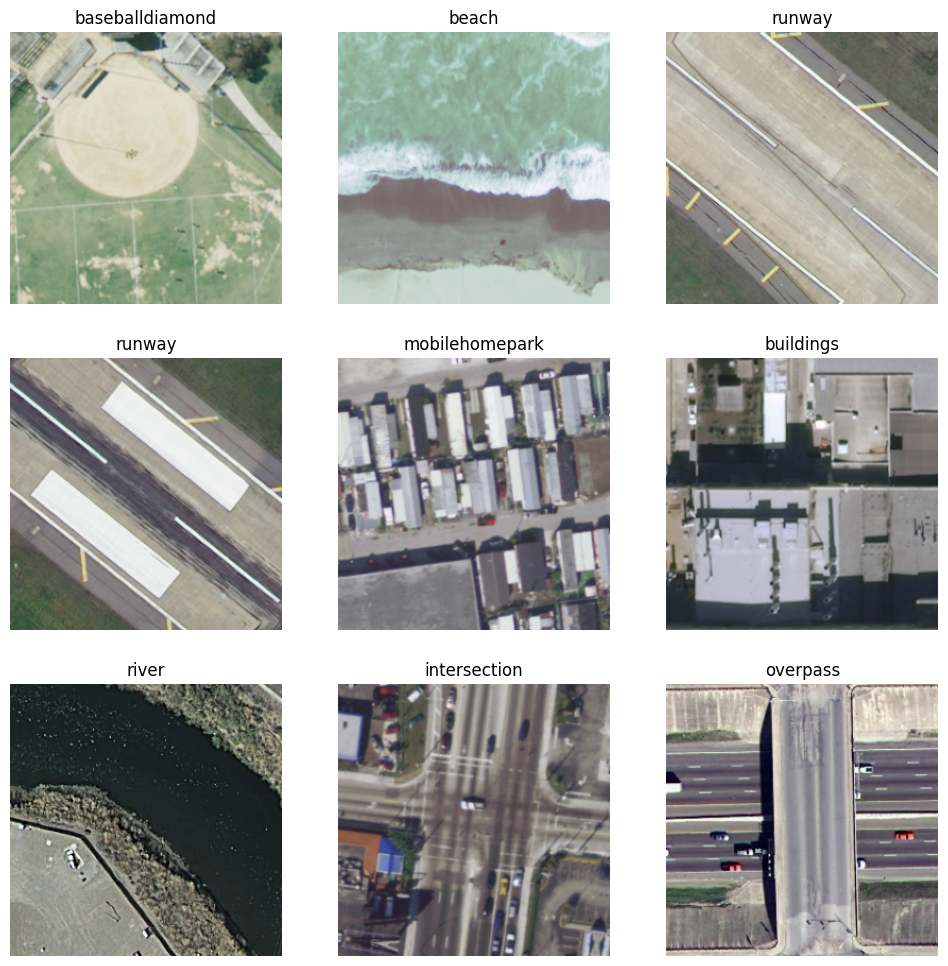

In [14]:
# DataLoaders
dls = dblock.dataloaders(path, bs=32)

# Vérification
dls.show_batch(max_n=9, figsize=(12,12))




In [15]:

print(f"\nNombre total de classes : {len(dls.vocab)}")


Nombre total de classes : 21


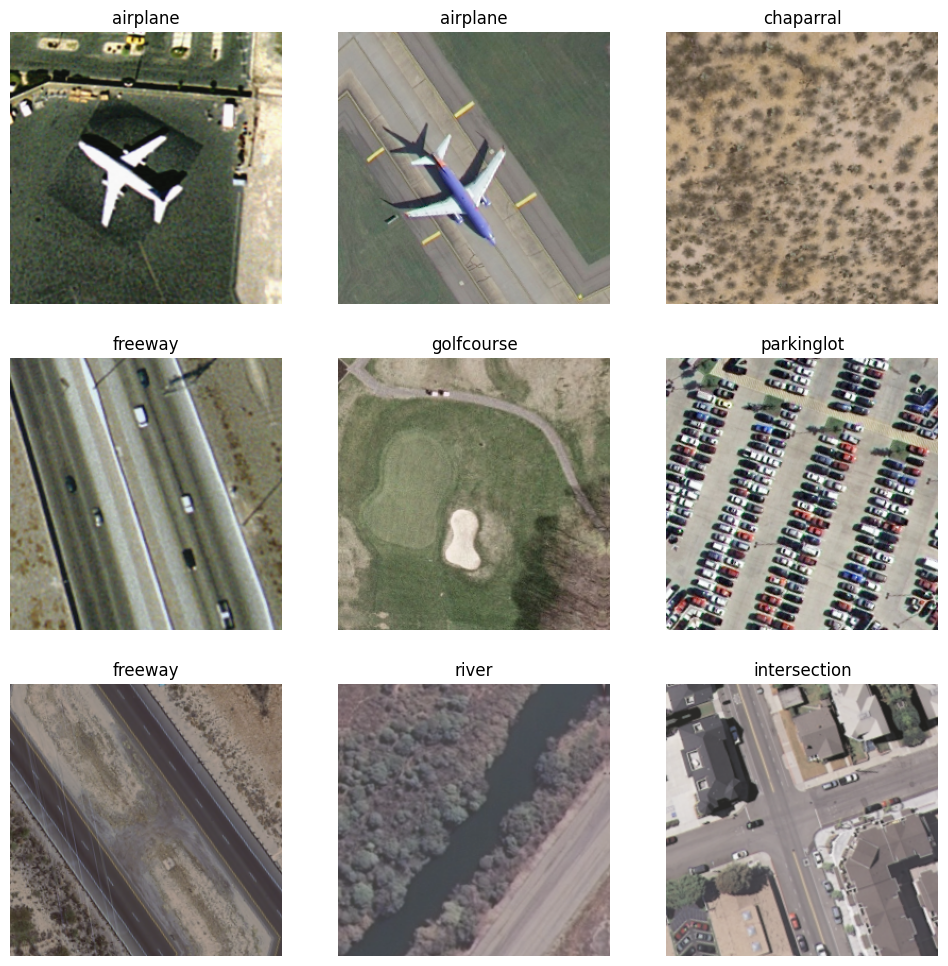

In [16]:
# DataBlock avancé
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_label,
    item_tfms=Resize(256),
    batch_tfms=[*aug_transforms(
        flip_vert=True,
        max_rotate=20,
        max_zoom=1.2,
        max_lighting=0.2,
        max_warp=0.1
    ), Normalize.from_stats(*imagenet_stats)]
)

# Créer les DataLoaders
dls = dblock.dataloaders(path, bs=32)

# Vérifier un batch
dls.show_batch(max_n=9, figsize=(12,12))

In [17]:
# resnet50 étant plus profond → meilleure précision qu’un resnet18, je choisis resnet50
learn = cnn_learner(dls, resnet50, metrics=accuracy)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


<div></div>

SuggestedLRs(valley=0.0020892962347716093)

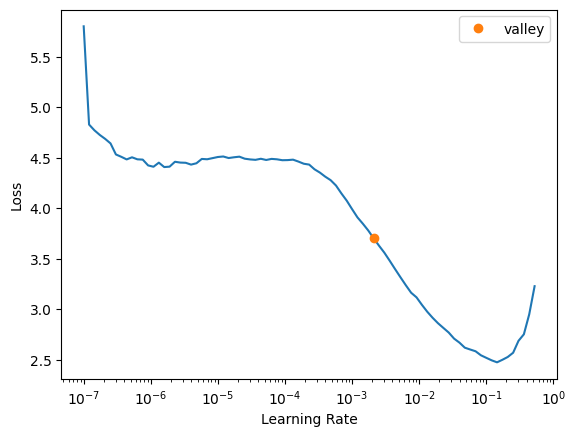

In [ ]:
learn.lr_find()

In [18]:
# Entrainement du modele, avec enregistrement du model et affichage des graphes
# Callbacks
cbs = [
    SaveModelCallback(monitor='accuracy'),
    CSVLogger()  # 🔥 enregistre les métriques
]

# Train
learn.fine_tune(10, base_lr=1e-2, cbs=cbs)

epoch,train_loss,valid_loss,accuracy,time
0,1.248755,0.546175,0.850000,00:18


Better model found at epoch 0 with accuracy value: 0.8500000238418579.


epoch,train_loss,valid_loss,accuracy,time
0,0.443567,0.207432,0.928571,00:22
1,0.276269,0.236539,0.933333,00:23
2,0.354732,0.448637,0.885714,00:22
3,0.412549,0.454797,0.907143,00:23
4,0.328312,0.392480,0.900000,00:24
5,0.216250,0.163670,0.947619,00:24
6,0.125263,0.142119,0.954762,00:24
7,0.076517,0.131744,0.964286,00:24
8,0.053834,0.118496,0.964286,00:24
9,0.045213,0.117750,0.961905,00:24


Better model found at epoch 0 with accuracy value: 0.9285714030265808.
Better model found at epoch 1 with accuracy value: 0.9333333373069763.
Better model found at epoch 5 with accuracy value: 0.9476190209388733.
Better model found at epoch 6 with accuracy value: 0.9547619223594666.
Better model found at epoch 7 with accuracy value: 0.9642857313156128.


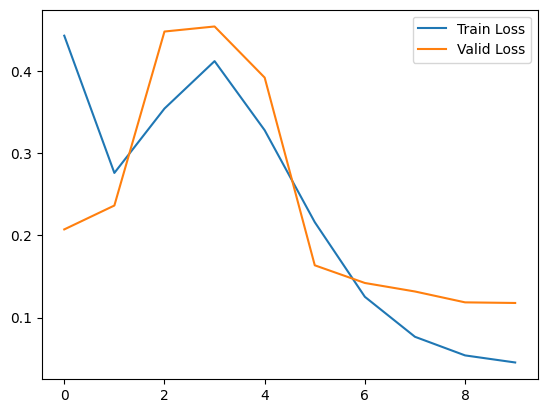

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = learn.recorder.values
train_losses = [x[0] for x in metrics]
valid_losses = [x[1] for x in metrics]

plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.legend()
plt.show()

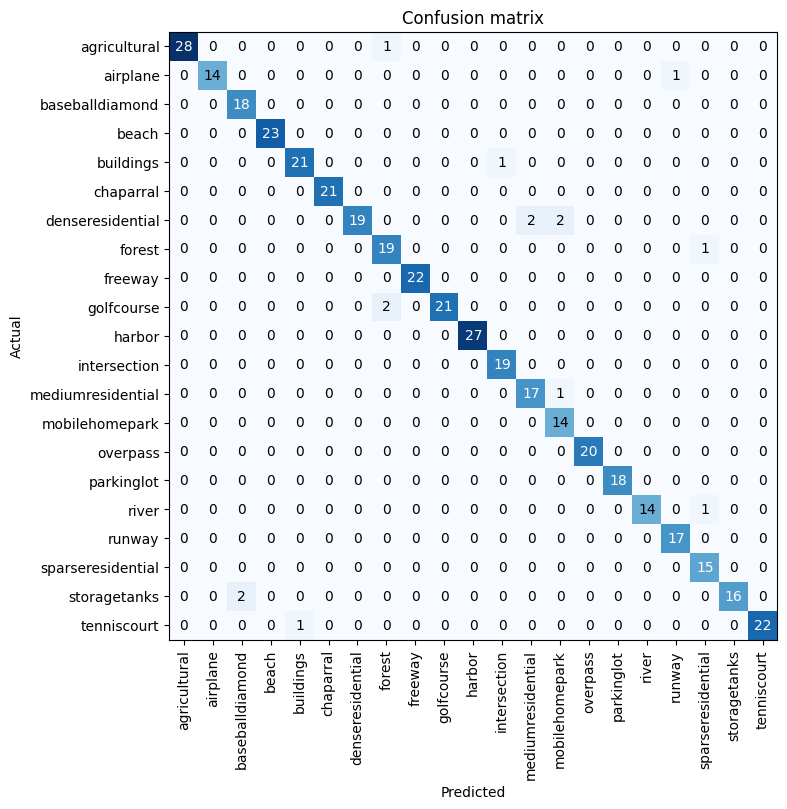

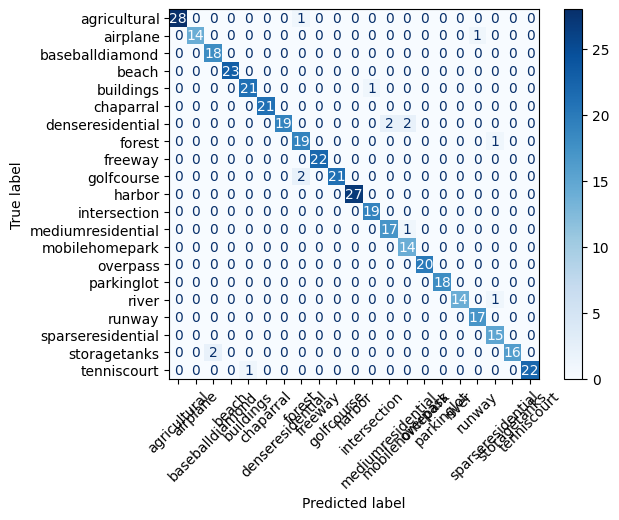

In [26]:
from fastai.vision.all import *
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# suppose que 'learn' est ton cnn_learner déjà entraîné
interp = ClassificationInterpretation.from_learner(learn)

# Affichage simple avec FastAI
interp.plot_confusion_matrix(figsize=(8,8), dpi=100)

# Si tu veux plus de contrôle avec sklearn
cm = interp.confusion_matrix()
labels = learn.dls.vocab  # liste des classes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.show()

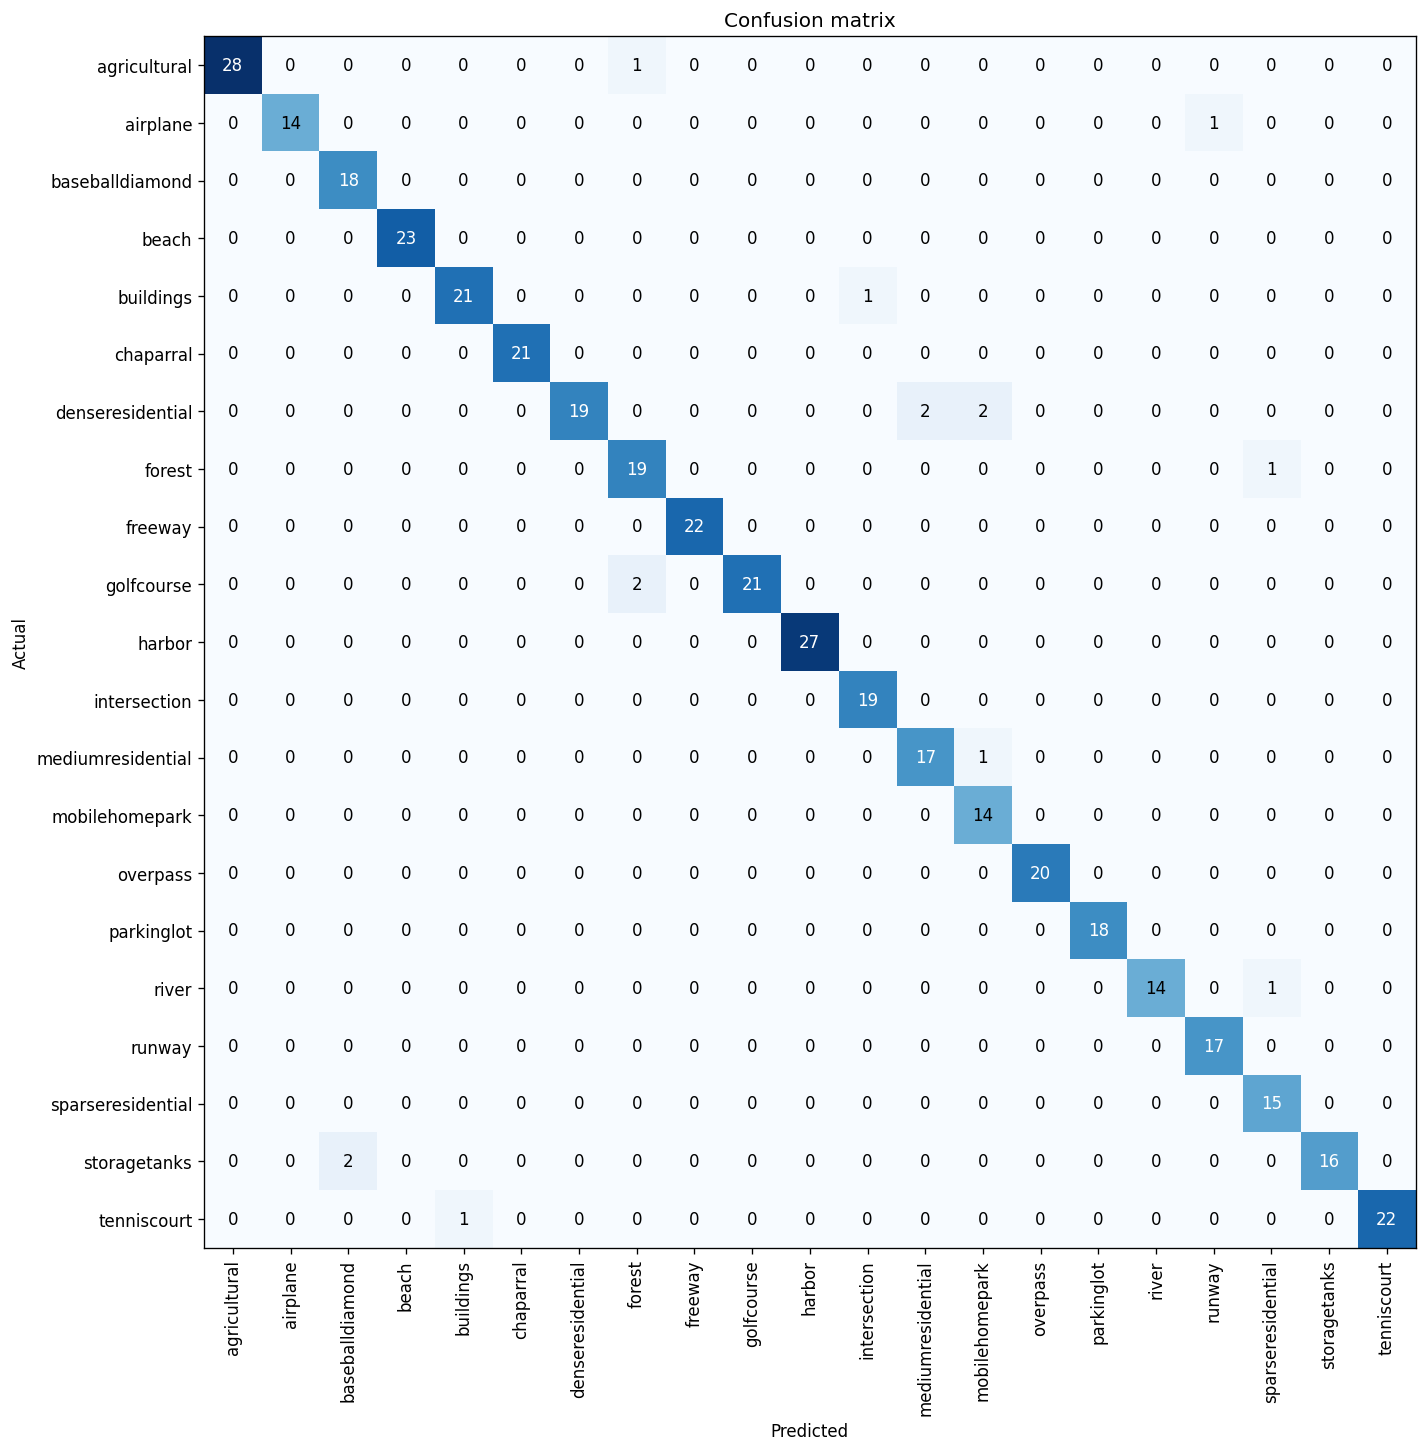

In [28]:
# POur augmenter la taille de la matrice de confusion
interp.plot_confusion_matrix(figsize=(12,12), dpi=120)

In [31]:
pip install seaborn

In [33]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [34]:
import seaborn
plt.style.use('dark_background')

In [39]:
# Récupérer les métriques depuis le recorder de FastAI
# learn.recorder.values contient [train_loss, valid_loss, metrics...]
if len(learn.recorder.values[0]) > 2:  # vérifier qu'il y a au moins une métrique
    accuracies = [v[2] for v in learn.recorder.values]  # récupère accuracy
else:
    accuracies = None  # sinon on ne trace rien

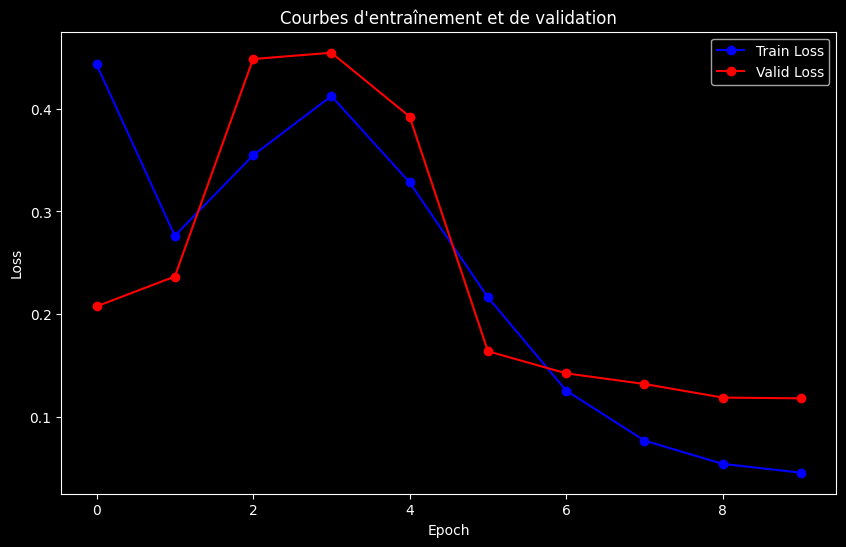

In [40]:
plt.style.use('dark_background')   # style valide

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(train_losses, label='Train Loss', marker='o', color='blue')
ax1.plot(valid_losses, label='Valid Loss', marker='o', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Courbes d\'entraînement et de validation')
ax1.legend(loc='upper right')

if accuracies:
    ax2 = ax1.twinx()
    ax2.plot(accuracies, label='Accuracy', color='green', linestyle='--', marker='x')
    ax2.set_ylabel('Accuracy')
    ax2.legend(loc='lower right')

plt.show()

In [41]:
# Faison quelques test sur le modèle

!wget https://www.dropbox.com/s/6tt0t61uq2w1n3s/test.zip
!unzip test.zip

--2026-04-04 22:49:21--  https://www.dropbox.com/s/6tt0t61uq2w1n3s/test.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/3c1r3xm1z8q225hqhuf7h/test.zip?rlkey=3xqce3ujgj3iw992z31dszc00 [following]
--2026-04-04 22:49:21--  https://www.dropbox.com/scl/fi/3c1r3xm1z8q225hqhuf7h/test.zip?rlkey=3xqce3ujgj3iw992z31dszc00
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc43612bc91a427a7ed3097f6e5a.dl.dropboxusercontent.com/cd/0/inline/C9_oGPH3ZHVYsOX0jXePp0VwOh-BNLUkC6VjXHXd6QmbJhsBzqeIq6pLBMruoyk0798vQCqN8K2ua467SA1rqS8YFkOlkl0NHUaKLRH4qo2ZzTzhjtUeaEQuj7pYQ6juc-mpJhb6eoRnNwQg3bQG6k1O/file# [following]
--2026-04-04 22:49:22--  https://uc43612bc91a427a7ed3097f6e5a.dl.dropboxusercontent.com/cd/0/inline/C9_oGPH3ZHVY

<Axes: >

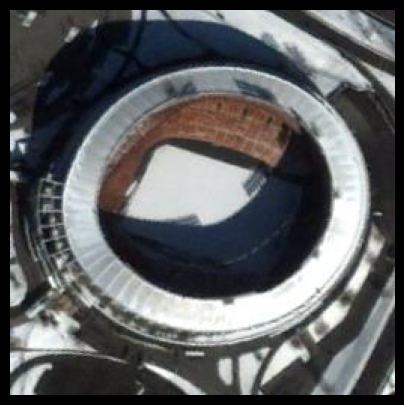

In [43]:
from fastai.vision.all import *

# Remplace open_image("path") par :
img = PILImage.create("/content/test/stadium_040.jpg")

# Vérifier l'image
img.show()



In [44]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'storagetanks'

<Axes: >

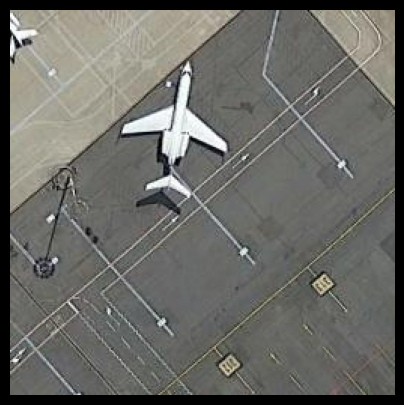

In [45]:
# Remplace open_image("path") par :
img = PILImage.create("/content/test/airplane_439.jpg")

# Vérifier l'image
img.show()

In [46]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'airplane'

<Axes: >

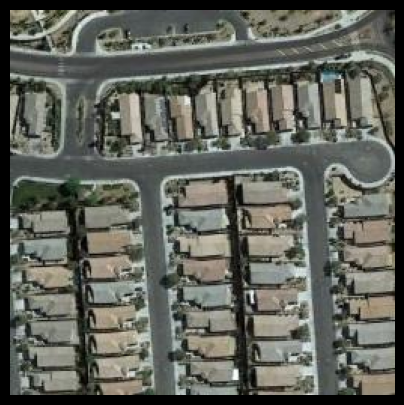

In [48]:
# Remplace open_image("path") par :
img = PILImage.create("/content/test/dense_residential_025.jpg")

# Vérifier l'image
img.show()

In [49]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'mobilehomepark'

<Axes: >

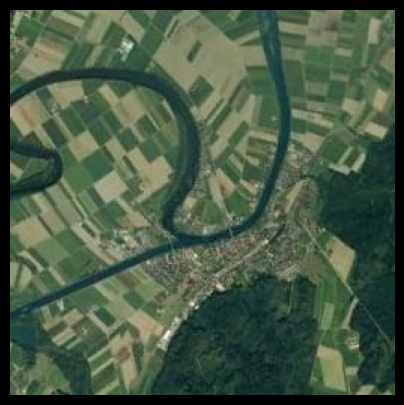

In [50]:
# Remplace open_image("path") par :
img = PILImage.create("/content/test/river_209.jpg")

# Vérifier l'image
img.show()

In [51]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'denseresidential'

<Axes: >

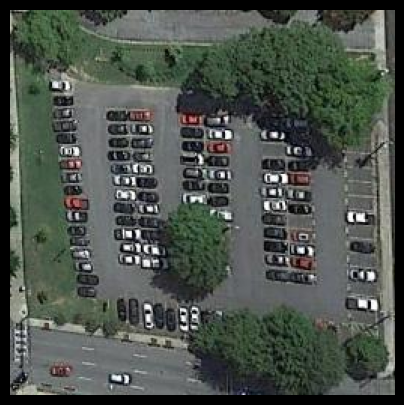

In [53]:
# Remplace open_image("path") par :
img = PILImage.create("/content/test/parking_lot_032.jpg")

# Vérifier l'image
img.show()

In [54]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'parkinglot'

<Axes: >

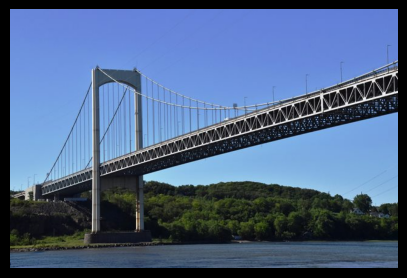

In [59]:
# Remplace open_image("path") par :
img = PILImage.create("/content/drive/MyDrive/Dossier sans titre/Pont Pierre Laporte.jpg")

# Vérifier l'image
img.show()

In [60]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'buildings'

<Axes: >

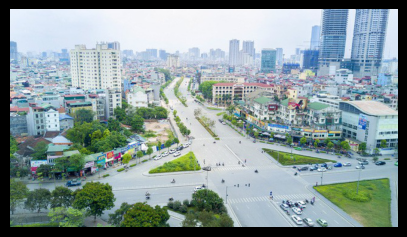

In [61]:
# Remplace open_image("path") par :
img = PILImage.create("/content/drive/MyDrive/Dossier sans titre/cau giay.png")

# Vérifier l'image
img.show()

In [62]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'buildings'

<Axes: >

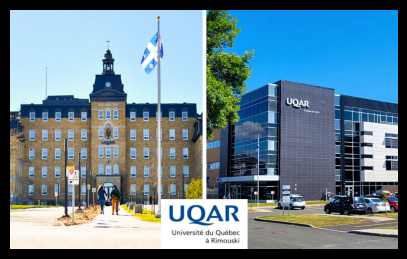

In [63]:
# Remplace open_image("path") par :
img = PILImage.create("/content/drive/MyDrive/Dossier sans titre/uqar_rimouskilevis.jpg")

# Vérifier l'image
img.show()

In [64]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'buildings'

In [65]:
learn.export('resnet50_ucmerced.pkl')